In [1]:
import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sns

import os

from PIL import Image

import warnings
warnings.filterwarnings("ignore")

import torch

import torch.nn as nn
import torch.optim as optim

import torchvision

from torchvision.transforms import transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using {device}")

using cuda


In [3]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [4]:
labels = []
paths = []

for label in os.listdir("../datasets/bone_fracture_binary_classification"):
    for image_path in os.listdir(f"../datasets/bone_fracture_binary_classification/{label}"):
        labels.append(label)
        paths.append(f"../datasets/bone_fracture_binary_classification/{label}/{image_path}")
        
data_df = pd.DataFrame(zip(paths, labels), columns= ["image_path", "label"])
data_df.head()  

,image_path,label
0,../datasets/bone_fracture_binary_classificatio...,fractured
1,../datasets/bone_fracture_binary_classificatio...,fractured
2,../datasets/bone_fracture_binary_classificatio...,fractured
3,../datasets/bone_fracture_binary_classificatio...,fractured
4,../datasets/bone_fracture_binary_classificatio...,fractured


In [6]:
from utils.Preprocessing import create_dataloader

train_loader, val_loader = create_dataloader(dataframe= data_df, includeTest= False)

original dataframe shape: (9548, 2)
training dataframe shape: (7638, 2)
validation dataframe shape: (1910, 2)


In [7]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.to(device)

#freeze
for param in model.parameters():
    param.requires_grad = False

#новый классификатор
model.fc = nn.Linear(model.fc.in_features, data_df["label"].nunique())
model.to(device) 

#оптимизатор только для fc
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [8]:
from utils.LearningFuncs import train_model

history = train_model(model= model, 
        train_loader= train_loader, 
        val_loader= val_loader, 
        criterion= criterion, 
        optimizer= optimizer, 
        device= device, 
        num_epochs= 10)

Epoch 1, Train loss: 0.5642, Validation loss: 0.4871,          Train accuracy: 0.6978, Validation accuracy: 0.7832
Epoch 2, Train loss: 0.4755, Validation loss: 0.4650,          Train accuracy: 0.7719, Validation accuracy: 0.7848
Epoch 3, Train loss: 0.4501, Validation loss: 0.4313,          Train accuracy: 0.7913, Validation accuracy: 0.8026
Epoch 4, Train loss: 0.4379, Validation loss: 0.4324,          Train accuracy: 0.7967, Validation accuracy: 0.8016
Epoch 5, Train loss: 0.4265, Validation loss: 0.4118,          Train accuracy: 0.8022, Validation accuracy: 0.8120
Epoch 6, Train loss: 0.4142, Validation loss: 0.4169,          Train accuracy: 0.8071, Validation accuracy: 0.8084
Epoch 7, Train loss: 0.4184, Validation loss: 0.4607,          Train accuracy: 0.8085, Validation accuracy: 0.7785
Epoch 8, Train loss: 0.4102, Validation loss: 0.4098,          Train accuracy: 0.8142, Validation accuracy: 0.8120
Epoch 9, Train loss: 0.4092, Validation loss: 0.4162,          Train accuracy: 0

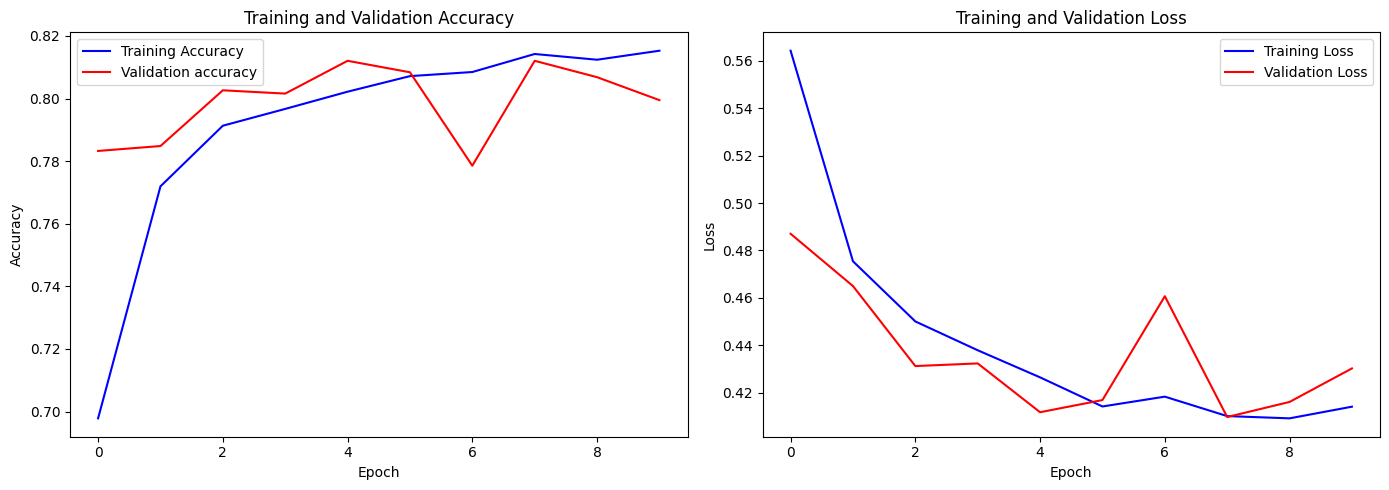

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history["Epoch"], history["Train accuracy"], label= "Training Accuracy", color= "blue")
axs[0].plot(history["Epoch"], history["Validation accuracy"], label= "Validation accuracy", color= "red")
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()

axs[1].plot(history["Epoch"], history["Train Loss"], label= "Training Loss", color= "blue")
axs[1].plot(history["Epoch"], history["Validation Loss"], label= "Validation Loss", color= "red")
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

In [10]:
#unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# оптимизатор только для обучаемых параметров
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


history = pd.concat([history, train_model(model= model, 
                                    train_loader= train_loader, 
                                    val_loader= val_loader, 
                                    criterion= criterion, 
                                    optimizer= optimizer, 
                                    device= device, 
                                    num_epochs= 10)])

history["Epoch"] = range(1, history.shape[0] +1)

Epoch 1, Train loss: 0.1801, Validation loss: 0.0674,          Train accuracy: 0.9254, Validation accuracy: 0.9775
Epoch 2, Train loss: 0.0610, Validation loss: 0.0543,          Train accuracy: 0.9779, Validation accuracy: 0.9785
Epoch 3, Train loss: 0.0394, Validation loss: 0.0275,          Train accuracy: 0.9857, Validation accuracy: 0.9916
Epoch 4, Train loss: 0.0314, Validation loss: 0.0313,          Train accuracy: 0.9889, Validation accuracy: 0.9885
Epoch 5, Train loss: 0.0221, Validation loss: 0.0274,          Train accuracy: 0.9918, Validation accuracy: 0.9906
Epoch 6, Train loss: 0.0213, Validation loss: 0.0188,          Train accuracy: 0.9918, Validation accuracy: 0.9963
Epoch 7, Train loss: 0.0183, Validation loss: 0.0173,          Train accuracy: 0.9925, Validation accuracy: 0.9969
Epoch 8, Train loss: 0.0208, Validation loss: 0.0326,          Train accuracy: 0.9918, Validation accuracy: 0.9890
Epoch 9, Train loss: 0.0117, Validation loss: 0.0252,          Train accuracy: 0

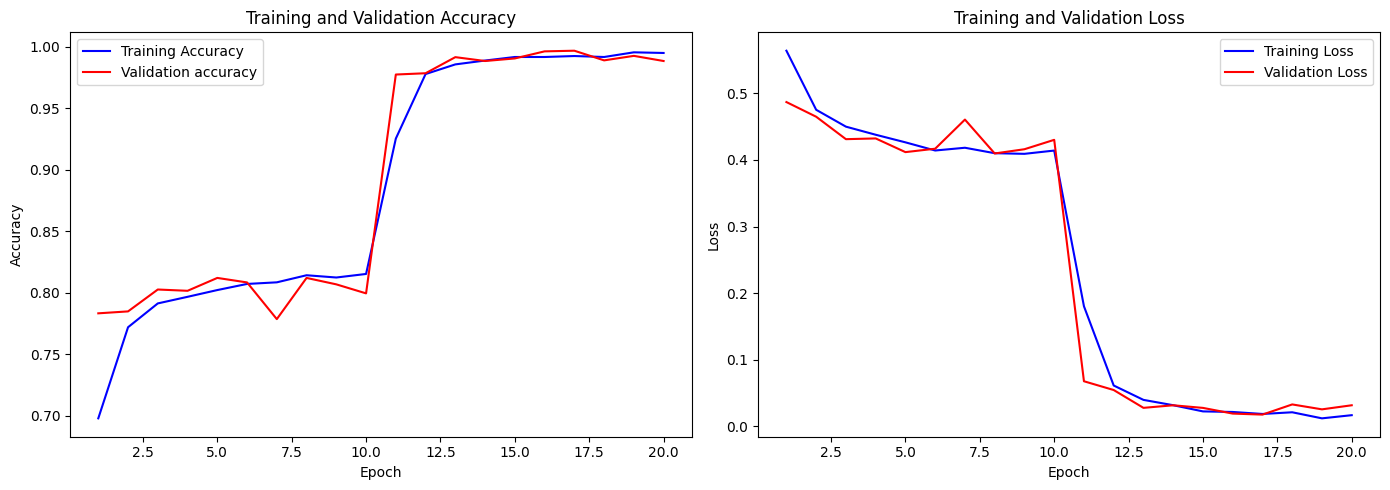

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history["Epoch"], history["Train accuracy"], label= "Training Accuracy", color= "blue")
axs[0].plot(history["Epoch"], history["Validation accuracy"], label= "Validation accuracy", color= "red")
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()

axs[1].plot(history["Epoch"], history["Train Loss"], label= "Training Loss", color= "blue")
axs[1].plot(history["Epoch"], history["Validation Loss"], label= "Validation Loss", color= "red")
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

In [12]:
torch.save(model.state_dict(), "../models/Bone_Fracture.pt")

In [13]:
torch.cuda.empty_cache()

!nvidia-smi

Tue Jul 28 18:03:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.74                 KMD Version: 610.74        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   64C    P3             21W /   93W |     348MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----